# Baseline Machine Learning Models

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from pathlib import Path
import warnings

from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

from data_loader import EEGDataLoader, get_default_data_path
from preprocessing import EEGPreprocessor, FeatureExtractor, create_binary_labels

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

## Load and Preprocess Data

In [52]:
data_path = get_default_data_path()
loader = EEGDataLoader(str(data_path))

summary_df = loader.create_summary_dataframe()
block_columns = ['honest_true', 'deceitful_true', 'honest_fake', 'deceitful_fake']
complete_participants = summary_df[summary_df[block_columns].all(axis=1)]

participants_to_use = complete_participants['participant_id'].tolist()

print(f"Total participants available: {len(loader.participants)}")
print(f"Complete participants (all 4 blocks): {len(complete_participants)}")
print(f"\nUsing {len(participants_to_use)} complete participants for training")

Skipping excluded folder: 6A517891 - stare dane
Skipping excluded folder: Popsute dane - ASD793JD
Successfully loaded metadata with encoding: cp1250
Found 15 participants
Loaded metadata for 16 participants
Total participants available: 15
Complete participants (all 4 blocks): 15

Using 15 complete participants for training


In [53]:
preprocessor = EEGPreprocessor(
    l_freq=0.5,
    h_freq=40.0,
    notch_freq=50.0,
    epoch_tmin=-0.2,
    epoch_tmax=0.8
)

feature_extractor = FeatureExtractor(sampling_freq=250.0)

In [54]:
test_participant = complete_participants.iloc[0]['participant_id']
test_data = loader.load_participant_data(test_participant)
test_block = list(test_data.keys())[0]
test_raw = test_data[test_block]

print(f"Checking {test_participant} - {test_block}")
print(f"Annotations: {len(test_raw.annotations)}")

events, event_id = mne.events_from_annotations(test_raw, verbose=True)
print(f"Events extracted: {len(events)}")
print(f"Event IDs: {event_id}")

if len(events) > 0:
    print(f"First few events:")
    print(events[:10])

  Loaded honest_true: 74575 samples, 21 channels, 250.0 Hz
  Loaded deceitful_true: 82275 samples, 21 channels, 250.0 Hz
  Loaded honest_fake: 79525 samples, 21 channels, 250.0 Hz
  Loaded deceitful_fake: 78625 samples, 21 channels, 250.0 Hz
Checking 02F6BC66 - honest_true
Annotations: 216
Used Annotations descriptions: [np.str_('ParticipantResponse.NO'), np.str_('ParticipantResponse.YES'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.RANDO'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.REAL'), np.str_('PersonalDataField.HOMETOWN: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.HOMETOWN: PersonalDataType.RANDO'), np.str_('PersonalDataField.HOMETOWN: PersonalDataType.REAL'), np.str_('PersonalDataField.NAME: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.NAME: PersonalDataType.RANDO'), np.str_('PersonalDataField.NAME: PersonalDataType.REAL')]
Events extracted: 216
Event IDs: {np

In [55]:
events, event_dict = mne.events_from_annotations(test_raw, verbose=False)

print(f"All events: {len(events)} total")
print(f"Event types: {list(event_dict.keys())[:5]}...")

stimulus_event_ids = {k: v for k, v in event_dict.items() if 'PersonalDataField' in k}
print(f"\nStimulus events: {len(stimulus_event_ids)} types")
print(f"IDs: {list(stimulus_event_ids.keys())}")

for name, id_ in list(stimulus_event_ids.items())[:3]:
    count = np.sum(events[:, 2] == id_)
    print(f"  {name}: {count} events")

print("\nCreating epochs...")
test_epochs_manual = mne.Epochs(test_raw, events, stimulus_event_ids,
                                tmin=-0.2, tmax=0.8,
                                baseline=(-0.2, 0),
                                reject=dict(eeg=150e-6),
                                preload=True, verbose=True)

All events: 216 total
Event types: [np.str_('ParticipantResponse.NO'), np.str_('ParticipantResponse.YES'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.RANDO'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.REAL')]...

Stimulus events: 9 types
IDs: [np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.RANDO'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.REAL'), np.str_('PersonalDataField.HOMETOWN: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.HOMETOWN: PersonalDataType.RANDO'), np.str_('PersonalDataField.HOMETOWN: PersonalDataType.REAL'), np.str_('PersonalDataField.NAME: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.NAME: PersonalDataType.RANDO'), np.str_('PersonalDataField.NAME: PersonalDataType.REAL')]
  PersonalDataField.BIRTH_DATE: PersonalDataType.CELEBRITY: 3 events
  PersonalDataField.B

In [56]:
print(f"Result: Created {len(test_epochs_manual)} epochs")
print(f"Epoch shape: {test_epochs_manual.get_data().shape}")
print(f"Event types in epochs: {list(test_epochs_manual.event_id.keys())}")

Result: Created 0 epochs
Epoch shape: (0, 21, 251)
Event types in epochs: [np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.RANDO'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.REAL'), np.str_('PersonalDataField.HOMETOWN: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.HOMETOWN: PersonalDataType.RANDO'), np.str_('PersonalDataField.HOMETOWN: PersonalDataType.REAL'), np.str_('PersonalDataField.NAME: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.NAME: PersonalDataType.RANDO'), np.str_('PersonalDataField.NAME: PersonalDataType.REAL')]


In [57]:
test_epochs_no_reject = mne.Epochs(test_raw, events, stimulus_event_ids,
                                    tmin=-0.2, tmax=0.8,
                                    baseline=(-0.2, 0),
                                    reject=None,
                                    preload=True, verbose=False)
print(f"Created {len(test_epochs_no_reject)} epochs without rejection")

if len(test_epochs_no_reject) > 0:
    data = test_epochs_no_reject.get_data() * 1e6
    print(f"Data range: {np.min(data):.1f} to {np.max(data):.1f} µV")
    print(f"Mean amplitude: {np.mean(np.abs(data)):.1f} µV")

Created 108 epochs without rejection
Data range: -1246924786.0 to 74513000000.0 µV
Mean amplitude: 1863435357.3 µV


In [58]:
print("Testing filtering...")
test_raw_filtered = preprocessor.filter_raw(test_raw, copy=True)
print("Filtering complete")

data_filtered = test_raw_filtered.get_data() * 1e6
print(f"Filtered data range: {np.min(data_filtered):.1f} to {np.max(data_filtered):.1f} µV")
print(f"Mean amplitude: {np.mean(np.abs(data_filtered)):.1f} µV")

print("\nCreating epochs from filtered data...")
test_epochs_filtered = mne.Epochs(test_raw_filtered, events, stimulus_event_ids,
                                   tmin=-0.2, tmax=0.8,
                                   baseline=(-0.2, 0),
                                   reject=dict(eeg=500e-6),
                                   preload=True, verbose=False)
print(f"Created {len(test_epochs_filtered)} epochs with 500µV rejection threshold")

Testing filtering...
Filtering complete
Filtered data range: -1956528902.1 to 74574000000.0 µV
Mean amplitude: 1790746818.5 µV

Creating epochs from filtered data...
Created 0 epochs with 500µV rejection threshold


In [59]:
raw_filt = preprocessor.filter_raw(test_raw, copy=True)
print("Filtering done")

events_test, event_dict_test = mne.events_from_annotations(raw_filt, verbose=False)
stimulus_ids = {k: v for k, v in event_dict_test.items() if 'PersonalDataField' in k}
print(f"Found {len(stimulus_ids)} stimulus event types")
print(f"Total events: {len(events_test)}")

print("\nCreating epochs...")
epochs_test = mne.Epochs(raw_filt, events_test, stimulus_ids,
                         tmin=-0.2, tmax=0.8,
                         baseline=(-0.2, 0),
                         reject=None,
                         preload=True, verbose=True)
print(f"\nResult: {len(epochs_test)} epochs")

Filtering done
Found 9 stimulus event types
Total events: 216

Creating epochs...
Not setting metadata
108 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 108 events and 251 original time points ...
0 bad epochs dropped
108 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 108 events and 251 original time points ...
0 bad epochs dropped

Result: 108 epochs

Result: 108 epochs


In [60]:
pipeline_epochs = preprocessor.preprocess_pipeline(test_raw)
print(f"Returned: {len(pipeline_epochs)} epochs")
print(f"Events shape: {pipeline_epochs.events.shape}")
print(f"Event IDs: {list(pipeline_epochs.event_id.keys())[:3]}...")

  Created 108 epochs from 108 events
Returned: 108 epochs
Events shape: (108, 3)
Event IDs: [np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.CELEBRITY'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.RANDO'), np.str_('PersonalDataField.BIRTH_DATE: PersonalDataType.REAL')]...


In [61]:
import importlib
import preprocessing
importlib.reload(preprocessing)

preprocessor_new = preprocessing.EEGPreprocessor()
feature_extractor_new = preprocessing.FeatureExtractor()

new_epochs = preprocessor_new.preprocess_pipeline(test_raw)
print(f"Result: {len(new_epochs)} epochs")

if len(new_epochs) > 0:
    features = feature_extractor_new.extract_combined_features(new_epochs)
    print(f"Features extracted: {features.shape}")

  Created 108 epochs from 108 events
Result: 108 epochs
  Extracted features: 252 features per epoch
Features extracted: (108, 252)
  Extracted features: 252 features per epoch
Features extracted: (108, 252)


In [62]:
import importlib
import preprocessing
importlib.reload(preprocessing)

preprocessor = preprocessing.EEGPreprocessor()
feature_extractor = preprocessing.FeatureExtractor()

all_features = []
all_labels = []
all_participants_ids = []

for participant_id in participants_to_use:
    print(f"\nProcessing {participant_id}...")
    
    try:
        participant_data = loader.load_participant_data(participant_id)
        
        for block_name, raw in participant_data.items():
            print(f"  Block: {block_name}")
            
            epochs = preprocessor.preprocess_pipeline(raw)
            
            if len(epochs) == 0:
                print(f"    No valid epochs, skipping")
                continue
            
            features = feature_extractor.extract_combined_features(epochs)
            
            is_deceitful = 'deceitful' in block_name
            labels = np.ones(len(epochs)) if is_deceitful else np.zeros(len(epochs))
            
            all_features.append(features)
            all_labels.append(labels)
            all_participants_ids.extend([participant_id] * len(epochs))
            
            print(f"    {features.shape[0]} epochs, {features.shape[1]} features")
    
    except Exception as e:
        print(f"  Error: {e}")
        continue

X = np.vstack(all_features)
y = np.concatenate(all_labels)

print(f"\nDATASET CREATED")
print(f"{'='*60}")
print(f"Total epochs: {len(X)}")
print(f"Features per epoch: {X.shape[1]}")
print(f"Honest responses: {np.sum(y == 0)} ({np.sum(y == 0)/len(y)*100:.1f}%)")
print(f"Deceitful responses: {np.sum(y == 1)} ({np.sum(y == 1)/len(y)*100:.1f}%)")


Processing 02F6BC66...
  Loaded honest_true: 74575 samples, 21 channels, 250.0 Hz
  Loaded deceitful_true: 82275 samples, 21 channels, 250.0 Hz
  Loaded honest_fake: 79525 samples, 21 channels, 250.0 Hz
  Loaded deceitful_fake: 78625 samples, 21 channels, 250.0 Hz
  Block: honest_true
  Created 108 epochs from 108 events
  Extracted features: 252 features per epoch
    108 epochs, 252 features
  Block: deceitful_true
  Created 111 epochs from 111 events
  Extracted features: 252 features per epoch
    111 epochs, 252 features
  Block: honest_fake
  Created 109 epochs from 109 events
  Extracted features: 252 features per epoch
    109 epochs, 252 features
  Block: deceitful_fake
  Created 108 epochs from 108 events
  Extracted features: 252 features per epoch
    108 epochs, 252 features

Processing 1299BF1A...
  Loaded honest_true: 70175 samples, 21 channels, 250.0 Hz
  Loaded deceitful_true: 69050 samples, 21 channels, 250.0 Hz
  Loaded honest_fake: 71175 samples, 21 channels, 250.0

In [63]:
nan_count = np.isnan(X).sum()
print(f"Checking for NaN values... Total: {nan_count}")

if nan_count > 0:
    print("NaN per feature (non-zero):")
    nan_per_feature = np.isnan(X).sum(axis=0)
    nan_features = np.where(nan_per_feature > 0)[0]
    for feat_idx in nan_features[:10]:
        print(f"  Feature {feat_idx}: {nan_per_feature[feat_idx]} NaN values")
    
    inf_count = np.isinf(X).sum()
    print(f"Total Inf values: {inf_count}")
    
    print("\nCleaning data...")
    X_clean = X.copy()
    
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X_clean = imputer.fit_transform(X_clean)
    
    X_clean = np.nan_to_num(X_clean, nan=0.0, posinf=0.0, neginf=0.0)
    
    X = X_clean
    
    print(f"Data cleaned")
    print(f"  Remaining NaN: {np.isnan(X).sum()}")
    print(f"  Remaining Inf: {np.isinf(X).sum()}")
else:
    print("No NaN values found")

print(f"\nFinal dataset shape: {X.shape}")

Checking for NaN values... Total: 12926
NaN per feature (non-zero):
  Feature 155: 6463 NaN values
  Feature 156: 6463 NaN values
Total Inf values: 0

Cleaning data...
Data cleaned
  Remaining NaN: 0
  Remaining Inf: 0

Final dataset shape: (6463, 250)


## Person-Independent Cross-Validation

In [64]:
participant_ids = np.array(all_participants_ids)
unique_participants = np.unique(participant_ids)
n_participants = len(unique_participants)

print(f"Total epochs: {len(X)}")
print(f"Total participants: {n_participants}")
print(f"Participants: {unique_participants}")
print(f"\nUsing GroupKFold for person-independent validation")

Total epochs: 6463
Total participants: 15
Participants: ['02F6BC66' '1299BF1A' '2D663E30' '4C0F44CF' '827366EC' '8DB745E3'
 'A3627947' 'ASD6DSA7' 'BNFH348D' 'DAF24E45' 'E52DEA2D' 'HFDY7643'
 'SDF673HF' 'a59d58f4' 'ff0dc21c']

Using GroupKFold for person-independent validation


In [65]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features standardized")
print(f"Data shape: {X_scaled.shape}")
print(f"Features per epoch: {X_scaled.shape[1]}")

Features standardized
Data shape: (6463, 250)
Features per epoch: 250


## Feature Selection

In [66]:
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold

var_threshold = VarianceThreshold(threshold=0.01)
X_high_var = var_threshold.fit_transform(X_scaled)

print(f"Removing low-variance features...")
print(f"Features before: {X_scaled.shape[1]}")
print(f"Features after variance threshold: {X_high_var.shape[1]}")
print(f"Removed {X_scaled.shape[1] - X_high_var.shape[1]} low-variance features")

print(f"\nSelecting top features using F-score...")
k_best = min(100, X_high_var.shape[1])
selector = SelectKBest(f_classif, k=k_best)
X_selected = selector.fit_transform(X_high_var, y)

print(f"Final features selected: {X_selected.shape[1]}")
print(f"Total reduction: {X_scaled.shape[1]} → {X_selected.shape[1]} features")

X_scaled = X_selected

Removing low-variance features...
Features before: 250
Features after variance threshold: 231
Removed 19 low-variance features

Selecting top features using F-score...
Final features selected: 100
Total reduction: 250 → 100 features


## Train Models

In [67]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    'SVM': SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        random_state=42
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5,
        weights='distance',
        n_jobs=-1
    )
}

print("Models defined:")
for name in models.keys():
    print(f"  - {name}")

Models defined:
  - Random Forest
  - SVM
  - KNN


In [68]:
n_splits = min(5, n_participants // 2)
cv = GroupKFold(n_splits=n_splits)

print(f"Using GroupKFold with {n_splits} splits")
print(f"Person-independent evaluation for realistic generalization\n")

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    print(f"{'='*60}")
    
    cv_scores = cross_val_score(model, X_scaled, y, groups=participant_ids, cv=cv, scoring='accuracy')
    cv_precision = cross_val_score(model, X_scaled, y, groups=participant_ids, cv=cv, scoring='precision')
    cv_recall = cross_val_score(model, X_scaled, y, groups=participant_ids, cv=cv, scoring='recall')
    cv_f1 = cross_val_score(model, X_scaled, y, groups=participant_ids, cv=cv, scoring='f1')
    
    results[name] = {
        'model': model,
        'accuracy': cv_scores.mean(),
        'accuracy_std': cv_scores.std(),
        'precision': cv_precision.mean(),
        'recall': cv_recall.mean(),
        'f1': cv_f1.mean(),
        'cv_scores': cv_scores
    }
    
    print(f"\nCross-Validation Performance ({n_splits}-fold):")
    print(f"  Accuracy:  {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"  Precision: {cv_precision.mean():.4f} (+/- {cv_precision.std():.4f})")
    print(f"  Recall:    {cv_recall.mean():.4f} (+/- {cv_recall.std():.4f})")
    print(f"  F1-Score:  {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")

Using GroupKFold with 5 splits
Person-independent evaluation for realistic generalization


Training Random Forest...

Cross-Validation Performance (5-fold):
  Accuracy:  0.5113 (+/- 0.0345)
  Precision: 0.5015 (+/- 0.0452)
  Recall:    0.5576 (+/- 0.2033)
  F1-Score:  0.5147 (+/- 0.1186)

Training SVM...

Cross-Validation Performance (5-fold):
  Accuracy:  0.5113 (+/- 0.0345)
  Precision: 0.5015 (+/- 0.0452)
  Recall:    0.5576 (+/- 0.2033)
  F1-Score:  0.5147 (+/- 0.1186)

Training SVM...

Cross-Validation Performance (5-fold):
  Accuracy:  0.5025 (+/- 0.0192)
  Precision: 0.5030 (+/- 0.0182)
  Recall:    0.5315 (+/- 0.0898)
  F1-Score:  0.5137 (+/- 0.0471)

Training KNN...

Cross-Validation Performance (5-fold):
  Accuracy:  0.5025 (+/- 0.0192)
  Precision: 0.5030 (+/- 0.0182)
  Recall:    0.5315 (+/- 0.0898)
  F1-Score:  0.5137 (+/- 0.0471)

Training KNN...

Cross-Validation Performance (5-fold):
  Accuracy:  0.4868 (+/- 0.0194)
  Precision: 0.4879 (+/- 0.0195)
  Recall:    0.5373 

## Results Comparison

In [69]:
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [r['accuracy'] for r in results.values()],
    'Precision': [r['precision'] for r in results.values()],
    'Recall': [r['recall'] for r in results.values()],
    'F1-Score': [r['f1'] for r in results.values()],
    'Std': [r['accuracy_std'] for r in results.values()]
})

print("\nModel Comparison:")
display(results_df.round(4))

best_model_idx = results_df['F1-Score'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
print(f"\nBest model by F1-Score: {best_model_name}")


Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,Std
0,Random Forest,0.5113,0.5015,0.5576,0.5147,0.0345
1,SVM,0.5025,0.5030,0.5315,0.5137,0.0192
2,KNN,0.4868,0.4879,0.5373,0.5103,0.0194



Best model by F1-Score: Random Forest


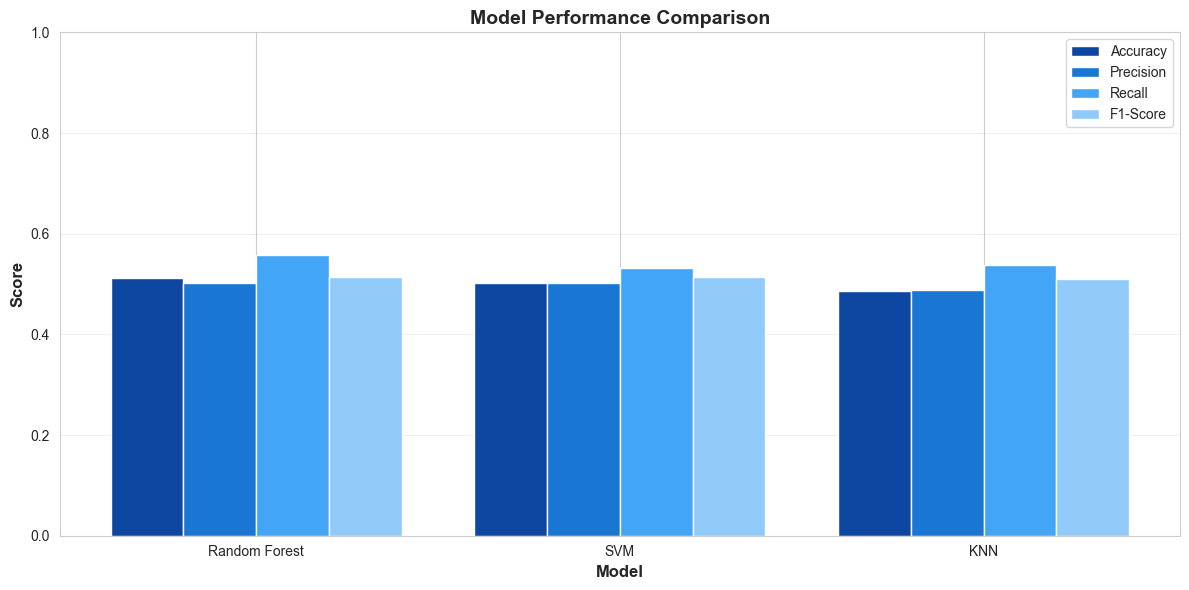

In [70]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.2

colors = ['#0D47A1', '#1976D2', '#42A5F5', '#90CAF9']

fig, ax = plt.subplots(figsize=(12, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i*width, results_df[metric], width, label=metric, color=colors[i])

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Model'])
ax.legend()
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

"plt.savefig('charts/baseline_model_performance.png', dpi=300, bbox_inches='tight')\n",
plt.show()

## Cross-Validation Scores

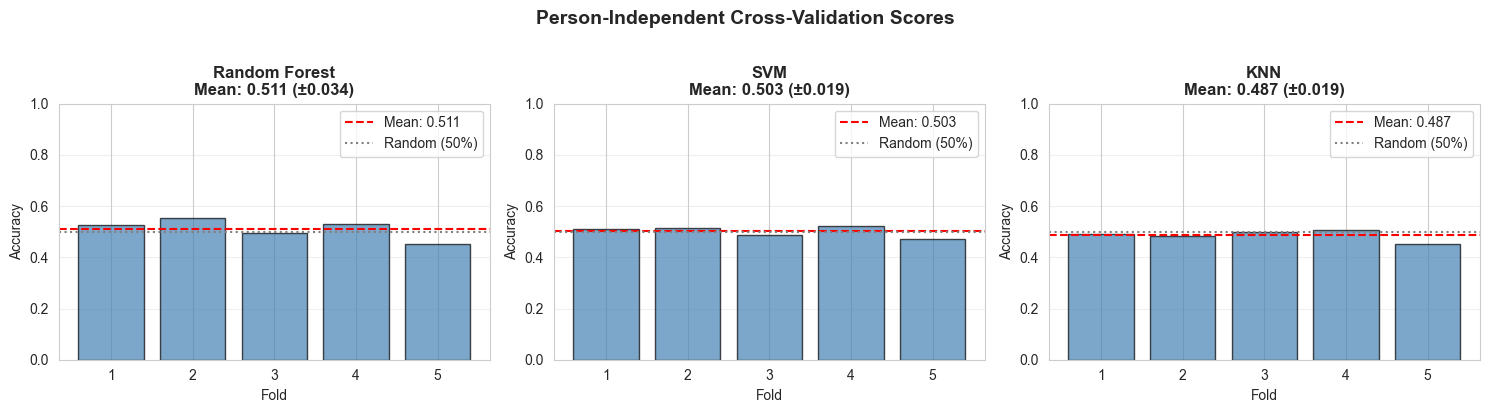

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, result) in enumerate(results.items()):
    scores = result['cv_scores']
    folds = np.arange(1, len(scores) + 1)
    
    axes[idx].bar(folds, scores, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx].axhline(y=scores.mean(), color='red', linestyle='--', label=f'Mean: {scores.mean():.3f}')
    axes[idx].axhline(y=0.5, color='gray', linestyle=':', label='Random (50%)')
    
    axes[idx].set_title(f'{name}\nMean: {scores.mean():.3f} (±{scores.std():.3f})', 
                       fontweight='bold')
    axes[idx].set_xlabel('Fold')
    axes[idx].set_ylabel('Accuracy')
    axes[idx].set_ylim([0, 1])
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Person-Independent Cross-Validation Scores', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

"plt.savefig('charts/baseline_cv_scores.png', dpi=300, bbox_inches='tight')\n",
plt.show()

## Confusion Matrices

Generate confusion matrices by collecting predictions across all cross-validation folds.

In [72]:
from sklearn.model_selection import cross_val_predict

print("Generating predictions across CV folds for confusion matrices...")

cm_results = {}

for name, result in results.items():
    model = result['model']
    y_pred = cross_val_predict(model, X_scaled, y, groups=participant_ids, cv=cv)
    cm = confusion_matrix(y, y_pred)
    accuracy = np.trace(cm) / np.sum(cm)
    
    cm_results[name] = {
        'cm': cm,
        'accuracy': accuracy,
        'y_pred': y_pred
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy:.3f}")
    print(f"  Confusion Matrix:")
    print(f"    {cm[0]}")
    print(f"    {cm[1]}")

print("\nConfusion matrices generated")

Generating predictions across CV folds for confusion matrices...

Random Forest:
  Accuracy: 0.511
  Confusion Matrix:
    [1497 1726]
    [1432 1808]

SVM:
  Accuracy: 0.503
  Confusion Matrix:
    [1526 1697]
    [1518 1722]

KNN:
  Accuracy: 0.487
  Confusion Matrix:
    [1405 1818]
    [1499 1741]

Confusion matrices generated


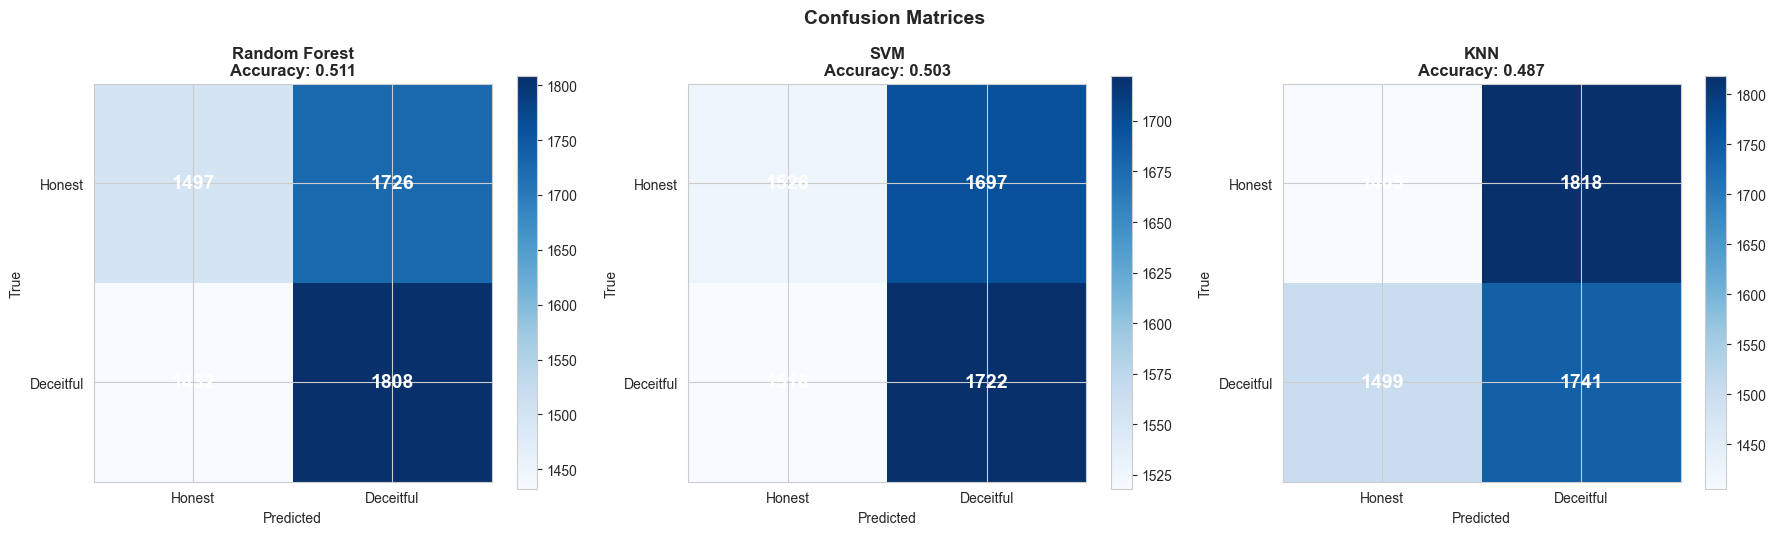

Confusion matrices saved to: results/baseline_confusion_matrices.png


In [73]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_names = list(cm_results.keys())
class_names = ['Honest', 'Deceitful']

for idx, name in enumerate(model_names):
    cm = cm_results[name]['cm']
    accuracy = cm_results[name]['accuracy']
    
    im = axes[idx].imshow(cm, interpolation='nearest', cmap='Blues')
    axes[idx].figure.colorbar(im, ax=axes[idx])
    
    axes[idx].set(xticks=np.arange(cm.shape[1]),
                  yticks=np.arange(cm.shape[0]),
                  xticklabels=class_names,
                  yticklabels=class_names,
                  xlabel='Predicted',
                  ylabel='True')
    
    axes[idx].set_title(f'{name}\nAccuracy: {accuracy:.3f}', 
                       fontsize=12, fontweight='bold')
    
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[idx].text(j, i, format(cm[i, j], 'd'),
                          ha="center", va="center",
                          color="white" if cm[i, j] > thresh else "black",
                          fontsize=14, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

"plt.savefig('charts/baseline_confusion_matrices.png', dpi=300, bbox_inches='tight')\n",
plt.show()

print("Confusion matrices saved to: results/baseline_confusion_matrices.png")

## Train Models on Full Dataset

In [74]:
for name, model in models.items():
    print(f"Training {name} on full dataset...")
    model.fit(X_scaled, y)
    results[name]['model'] = model

print("\nModels trained on full dataset")

Training Random Forest on full dataset...
Training SVM on full dataset...
Training SVM on full dataset...
Training KNN on full dataset...

Models trained on full dataset
Training KNN on full dataset...

Models trained on full dataset


## Summary

In [75]:
print(f"Dataset:")
print(f"   - Participants: {n_participants}")
print(f"   - Total epochs: {len(X)}")
print(f"   - Features: {X.shape[1]}")
print(f"   - Cross-validation: {n_splits}-fold GroupKFold")

print(f"\nBest Performing Model:")
best_result = results[best_model_name]
print(f"   - Model: {best_model_name}")
print(f"   - CV Accuracy: {best_result['accuracy']:.4f} (+/- {best_result['accuracy_std']:.4f})")
print(f"   - F1-Score: {best_result['f1']:.4f}")

Dataset:
   - Participants: 15
   - Total epochs: 6463
   - Features: 250
   - Cross-validation: 5-fold GroupKFold

Best Performing Model:
   - Model: Random Forest
   - CV Accuracy: 0.5113 (+/- 0.0345)
   - F1-Score: 0.5147
